# **NBA Aging Curve Solution Pipeline**

### **This notebook contains the project problem solution pipeline. The data stored in MongoDB in the data generating script will be loaded from the MongoDB database into a pandas DataFrame, and used to solve the project problem:**

Predicting how NBA player Box Plus Minus (BPM) changes as a function of age, position, and injury history in order to model career aging curves that inform future player progression or regression.

## **Pipeline Contents**

- Package Imports
- Logging
- Connecting to MongoDB
- Loading Data into DataFrame
- Feature Engineering
- Building Age Curve Model
- Analyzing Results
- Visualization of Results
- Conclusion

## **Imports**

The following packages are imported for use in the solution pipeline.

In [1]:
# Imports
import statsmodels.formula.api as smf
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import pymongo
import os

## **Logger Initialization**

This is the initialization of the logger used throughout the pipeline notebook.

In [2]:
# Initializing logger
logging.basicConfig(
    level = logging.INFO, 
    format = '%(asctime)s - %(levelname)s - %(message)s',  # Timestamp, level, and message format
    filename = 'pipeline.log'
)
logger = logging.getLogger(__name__)

## **Connecting to MongoDB**

This is the connection to the MongoDB database. Credentials are loaded in the the environment to maintain a secure database. The data is stored in the `players` collection of the `bref-data` database.

In [3]:
# Load MongoDB credentials from .env
try:
    MONGO_USERNAME = os.getenv("MONGO_USERNAME")
    MONGO_PASSWORD = os.getenv("MONGO_PASSWORD")
    MONGO_CLUSTER = os.getenv("MONGO_CLUSTER")
    MONGO_APP_NAME = os.getenv("MONGO_APP_NAME")
except Exception as e:
    print(f"Error loading environment variables: {e}")
    logger.error("Error loading environment variables")

# Connection string and client connection
try:
    conn = f"mongodb+srv://{MONGO_USERNAME}:{MONGO_PASSWORD}@{MONGO_CLUSTER}/?appName={MONGO_APP_NAME}"
    client = pymongo.MongoClient(conn)
except Exception as e:
    print(f"Error connecting to MongoDB: {e}")
    logger.error("Error connecting to MongoDB")

# Access the database and collection
db = client['bref-data']
collection = db['players']

# Show collection to verify
print(db.list_collection_names())
logger.info("Connected to MongoDB and accessed the 'players' collection")

['players']


## **Loading Data into DataFrame**

This is where the data from the MongoDB database is loaded into a Pandas DataFrame. The data is loaded such that each row represents a player-season (Ex. Steph Curry 2016).

In [4]:
# Get all documents from the collection
all_documents = collection.find({})
documents = list(all_documents)

# Use json_normalize to flatten the nested seasons array into a DataFrame
try:
    df = pd.json_normalize(
        documents,
        record_path = 'seasons',
        meta = ['_id', 'name']
    )
except Exception as e:
    print(f"Error normalizing JSON data: {e}")
    logger.error("Error normalizing JSON data")

# Reorder the columns so player identifiers are at the front
cols = ['_id', 'name'] + [col for col in df.columns if col not in ['_id', 'name']]
df = df[cols]

# Display the first few rows to verify
display(df.head(3))
logger.info("Data loaded into Pandas DataFrame")

,_id,name,season,age,team,games_played,games_started,games_missed,injury_flag,minutes_per_game,...,blocks_per_game,turnovers_per_game,PER,TS_pct,USG_pct,AST_pct,TOV_pct,WS,BPM,VORP
0,tracy_mcgrady,Tracy McGrady,2003-04,24,ORL,67,67,15,False,39.9,...,0.6,2.7,25.3,0.526,33.2,28.3,9.1,8.4,6.4,5.7
1,tracy_mcgrady,Tracy McGrady,2004-05,25,HOU,78,78,4,False,40.8,...,0.7,2.6,22.9,0.526,31.2,28.6,9.5,12.0,6.7,6.9
2,tracy_mcgrady,Tracy McGrady,2005-06,26,HOU,47,47,35,False,37.1,...,0.9,2.6,21.9,0.494,35.0,28.8,9.4,4.1,5.4,3.3


## **Feature Engineering**

This is where the pre-modeling feature engineering is done. The games played and minutes per game filters are used to ensure noise from low volume players does not adversely effect the model. Next, polynomial terms up to degree 4 are calculated for the age variable, allowing for greater nonlinearity in the age curve. Lastly, a lagged version of the injury flag is used to allow the model to understand injury frequency over the course of more than 1 season.

In [5]:
# Subset and filter data
df_model = df[(df["games_played"] >= 20) & (df["minutes_per_game"] >= 15)].copy()
df_model  = df_model.sort_values(["name", "season"]).reset_index(drop = True)

# Polynomial age features
df_model["age_2"] = df_model["age"] ** 2
df_model["age_3"] = df_model["age"] ** 3
df_model["age_4"]  = df_model["age"] ** 4


# Lagged injury flag
df_model["injured_last_season"] = (
    df_model
    .groupby("name")["injury_flag"]
    .shift(1)
    .fillna(False)
    .astype(int)
)

# Current season workload
df_model["minutes_per_game"] = df_model["minutes_per_game"].astype(float)

# Print and log
print("Completed feature engineering")
logger.info("Completed feature engineering")

Completed feature engineering


/tmp/ipykernel_10815/910325968.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


## **Building Age Curve Model**

The aging curve model can now be trained to predict BPM using age terms, minutes per game, usage, games missed, and past injury.

In [6]:
# Fit mixed effects model with random intercepts and slopes for age
model = smf.mixedlm(
    """BPM ~ age + age_2 + age_3 + age_4
           + minutes_per_game
           + USG_pct
           + games_missed
           + injured_last_season""",
    df_model,
    groups = df_model["name"],
    re_formula = "~age"
)
result = model.fit(method = "lbfgs")
print("Model fitted successfully")
logger.info("Model fitted successfully")

Model fitted successfully


## **Analyzing Results**

The results from the model fitting can be viewed here.

In [7]:
print(result.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     BPM        
No. Observations:     7107        Method:                 REML       
No. Groups:           1377        Scale:                  1.7412     
Min. group size:      1           Log-Likelihood:         -13678.4202
Max. group size:      23          Converged:              Yes        
Mean group size:      5.2                                            
---------------------------------------------------------------------
                     Coef.   Std.Err.    z    P>|z|  [0.025   0.975] 
---------------------------------------------------------------------
Intercept           -138.946   16.491  -8.425 0.000 -171.268 -106.623
age                   17.153    2.395   7.163 0.000   12.460   21.847
age_2                 -0.818    0.129  -6.351 0.000   -1.070   -0.565
age_3                  0.017    0.003   5.699 0.000    0.011    0.023
age_4                 -0.000    0.00

**Key Results:**

- Age follows a nonlinear career arc: Significant polynomial terms up to the 4th degree in age capture a rise in BPM through a player's mid-twenties before declining in later years
- Playing time and usage are strong predictors: Each additional minute per game is associated with a 0.077 increase in BPM, and each additional percentage point of usage with a 0.148 increase, though causal direction is uncertain for both
- Injury meaningfully reduces performance: Each game missed is associated with a 0.024 decrease in BPM, and players injured the prior season see an additional 0.226 decrease on average

## **Visualization of Results**

The visualization code plots individualized aging curves for two selected players against the league-average trajectory. Observed BPM is drawn as a solid line up to age 29, at which point a personalized projection is generated using each player's random effects and their most recent season's workload, extending the forecast to age 38. A shaded region distinguishes the projection window from the observed data, and the league-average curve serves as a population-level baseline for comparison.

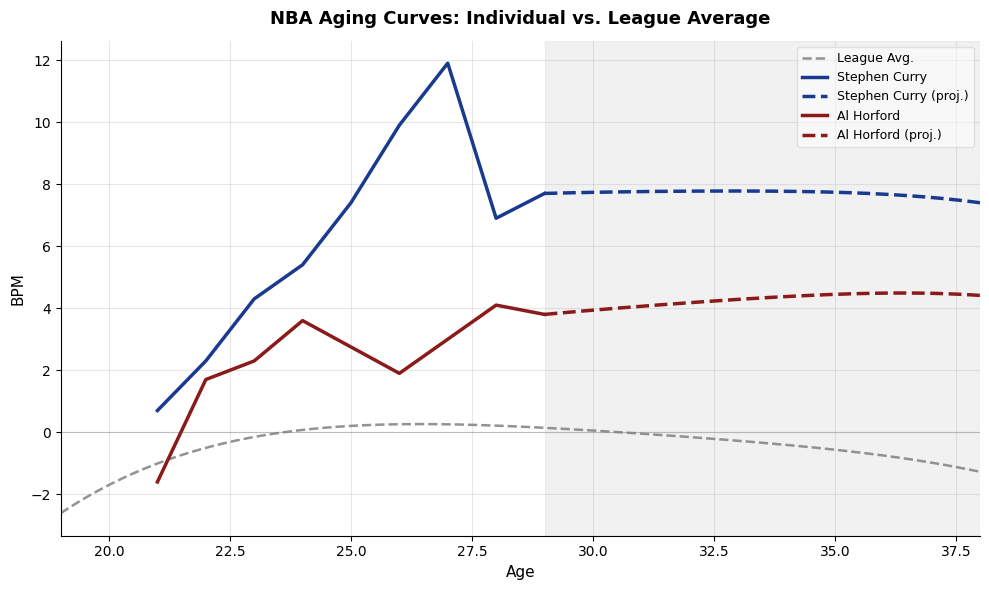

Visualization created and saved successfully


In [8]:
# Function to calculate league-average BPM at a given age, holding other factors constant
def fixed_bpm(age, result, minutes_per_game = 20, USG_pct = 20, games_missed = 0, injured_last_season = 0):
    p = result.fe_params
    return (
        p["Intercept"]
        + p["age"] * age
        + p["age_2"] * age**2
        + p["age_3"] * age**3
        + p["age_4"] * age**4
        + p["minutes_per_game"] * minutes_per_game
        + p["USG_pct"] * USG_pct
        + p["games_missed"] * games_missed
        + p["injured_last_season"] * injured_last_season
    )

# Function to calculate a player's predicted BPM at a given age,
# including both fixed effects and their specific random effects
def player_bpm_predicted(age, result, name, minutes_per_game = 20, USG_pct = 20, games_missed = 0):
    re = result.random_effects[name]
    fixed = fixed_bpm(age, result, minutes_per_game = minutes_per_game,
                      USG_pct = USG_pct, games_missed = games_missed)
    return fixed + re["Group"] + re["age"] * age

# Pull observed age, BPM, mpg, USG_pct, and games_missed sorted chronologically
def get_observed(name):
    sub = df_model[df_model["name"] == name].sort_values("age")
    return (sub["age"].values, sub["BPM"].values, sub["minutes_per_game"].values,
            sub["USG_pct"].values, sub["games_missed"].values)


# Define players and parameters for visualization
player_a = "Stephen Curry"
player_b = "Al Horford"
max_age  = 38
proj_age = 29
colors   = {"a": "#1a3a8f", "b": "#8b1a1a"}

# Initialize figure
fig, ax = plt.subplots(figsize = (10, 6))

# League average curve using mean values across all player-seasons
all_ages       = np.linspace(19, max_age, 400)
league_avg_mpg = df_model["minutes_per_game"].mean()
league_avg_usg = df_model["USG_pct"].mean()
ax.plot(all_ages, fixed_bpm(all_ages, result, minutes_per_game = league_avg_mpg,
                             USG_pct = league_avg_usg),
        color = "gray", linewidth = 1.8, linestyle = "--",
        alpha = 0.85, zorder = 2, label = "League Avg.")

# Plot observed data and projections for each player
for key, name in [("a", player_a), ("b", player_b)]:
    # Get color
    c = colors[key]

    # Get observed data for the player
    obs_age, obs_bpm, obs_mpg, obs_usg, obs_gm = get_observed(name)

    # Cutoff is whichever is lower — proj_age or the player's most recent season
    cutoff    = min(obs_age[-1], proj_age)
    cut_mask  = obs_age <= cutoff
    post_mask = obs_age > cutoff

    last_age = obs_age[cut_mask][-1]
    last_bpm = obs_bpm[cut_mask][-1]

    # Use last observed season as baseline for all projection values
    last_mpg = obs_mpg[cut_mask][-1]
    last_usg = obs_usg[cut_mask][-1]

    # Projection ages from cutoff to max_age
    proj_ages = np.linspace(last_age, max_age, 300)

    # Actual line up to cutoff
    ax.plot(obs_age[cut_mask], obs_bpm[cut_mask],
            color = c, linewidth = 2.5, zorder = 4,
            label = f"{name}")

    # Personal projection anchored to last observed BPM
    personal_proj  = player_bpm_predicted(proj_ages, result, name,
                                          minutes_per_game = last_mpg,
                                          USG_pct = last_usg)
    shift_personal = last_bpm - personal_proj[0]
    projected_bpm  = personal_proj + shift_personal

    # Dashed projection line for the player
    ax.plot(proj_ages, projected_bpm,
            color = c, linewidth = 2.5, linestyle = "--", zorder = 4,
            label = f"{name} (proj.)")

# Zero line
ax.axhline(0, color = "gray", linewidth = 0.8, linestyle = "-", alpha = 0.4)

# Shaded region marking the projection period
ax.axvspan(proj_age, max_age, color = "lightgray", alpha = 0.3, zorder = 0)

# Despine top and right
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Set labels, title, legend, limits, and grid
ax.legend(framealpha = 0.5, fontsize = 9, loc = "upper right")
ax.set_xlabel("Age", fontsize = 11)
ax.set_ylabel("BPM", fontsize = 11)
ax.set_title("NBA Aging Curves: Individual vs. League Average",
             fontsize = 13, fontweight = "bold", pad = 12)
ax.set_xlim(19, max_age)
ax.grid(True, alpha = 0.3, linewidth = 0.8)

# Save and show the plot
plt.tight_layout()
plt.savefig("img/bpm_aging_curves.png", dpi = 150, bbox_inches = "tight")
plt.show()

print("Visualization created and saved successfully")
logger.info("Visualization created and saved successfully")

## **Conclusion**

This analysis confirms that NBA player aging is an individual process, and that treating it as universal leaves meaningful signal on the table. The mixed effects model shows that while the average player peaks in their mid-twenties and declines steadily from there, individual trajectories vary substantially based on playing time, usage rate, and injury history. Steph Curry and Al Horford are projected to age more gracefully than the league average, based on how their careers had actually unfolded up to their age 29 seasons. This can be seen in their flatter, more positive projection form ages 29 and up than that of the league average curve. For NBA teams making long-term roster decisions, a framework like this offers projection built around the specific player, not the average one.